# Level 1 - Task 2: Basic Statistics & Data Visualization
### Intern: Jyothi Valluru
### Dataset: Telecom Customer Churn
**Objective:** Perform a descriptive statistical analysis, visualize distributions and relationships, and identify correlations between numerical features.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Going up two levels (../../) to reach the Datasets folder from Level 1/Task 2
df = pd.read_csv('../../Dataset/Churn Prediction Data/churn-bigml-80.csv')

# Set aesthetic style for plots
sns.set_theme(style="whitegrid")

# Display first 5 rows to confirm load
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 1. Descriptive Statistics
We will calculate the Mean, Median, Mode, and Standard Deviation for key numerical features like `Total day minutes` and `Customer service calls`.

In [8]:
# Selecting a few key numerical columns for analysis
cols = ['Account length', 'Total day minutes', 'Total eve minutes', 'Customer service calls']

# Creating a summary table for Mean, Median, and Std Dev
stats_summary = df[cols].agg(['mean', 'median', 'std']).transpose()

# Calculating Mode separately (as a column can have multiple modes)
stats_summary['mode'] = df[cols].mode().iloc[0]

# Displaying the statistical results
print("--- Basic Statistics Table ---")
print(stats_summary)

--- Basic Statistics Table ---
                              mean  median        std   mode
Account length          100.620405  100.00  39.563974   93.0
Total day minutes       179.481620  179.95  54.210350  162.3
Total eve minutes       200.386159  200.90  50.951515  169.9
Customer service calls    1.562641    1.00   1.311236    1.0


## 2. Visualizing Distribution
To understand the "spread" of the data, we use a Histogram. This helps us see if the data follows a Normal Distribution or if it is skewed.
**Boxplots** to identify outliers in the data.

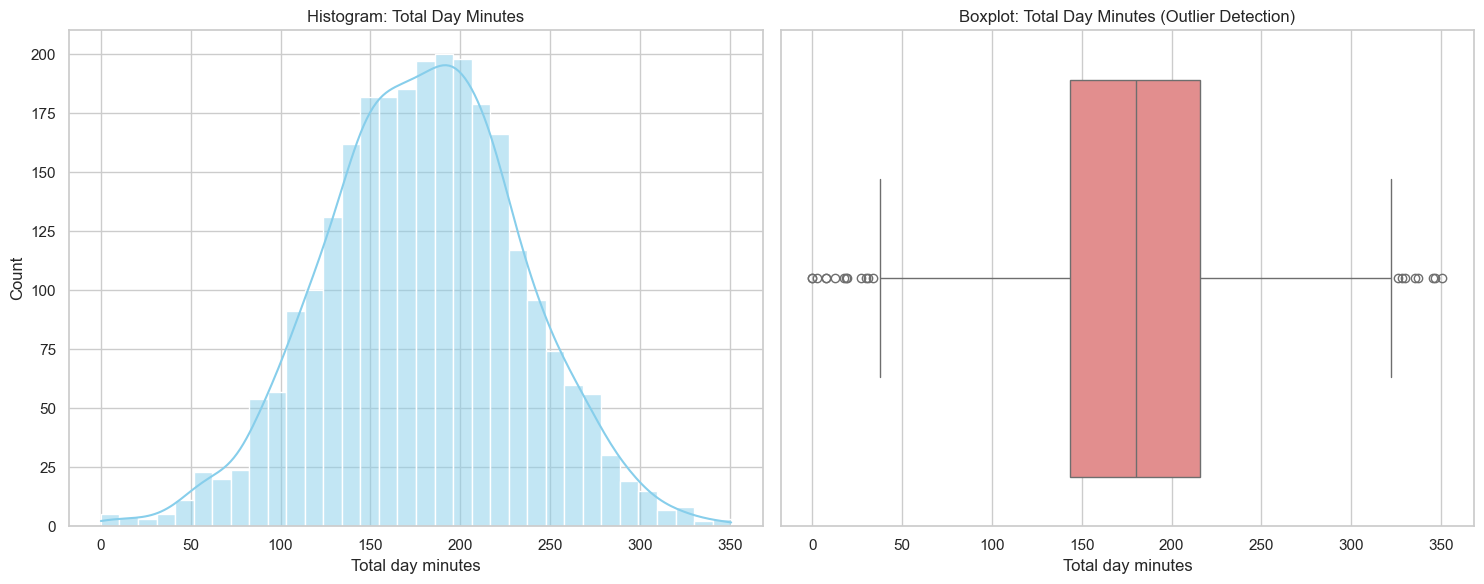

In [5]:
# Creating a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histogram for 'Total day minutes'
sns.histplot(df['Total day minutes'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram: Total Day Minutes')

# 2. Boxplot for 'Total day minutes' to find outliers
sns.boxplot(x=df['Total day minutes'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot: Total Day Minutes (Outlier Detection)')

plt.tight_layout()
plt.show()

## 2. Relationship Analysis (Scatter Plot)
We use a Scatter Plot to see if two variables move together. For example, we compare `Total day minutes` against `Total day charge`.

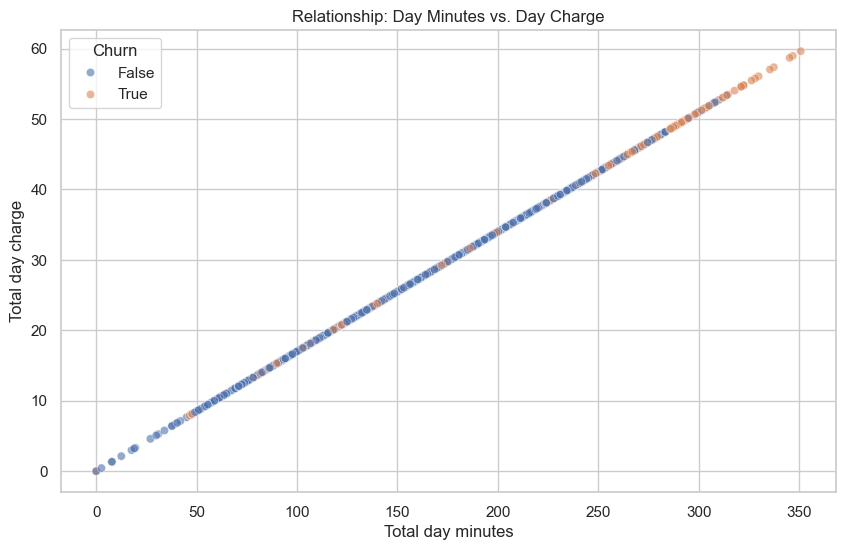

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Total day minutes', y='Total day charge', hue='Churn', alpha=0.6)
plt.title('Relationship: Day Minutes vs. Day Charge')
plt.show()

## 3. Correlation Matrix
We calculate the correlation coefficient to see how strongly numerical features are related. A value close to 1 indicates a strong positive relationship.

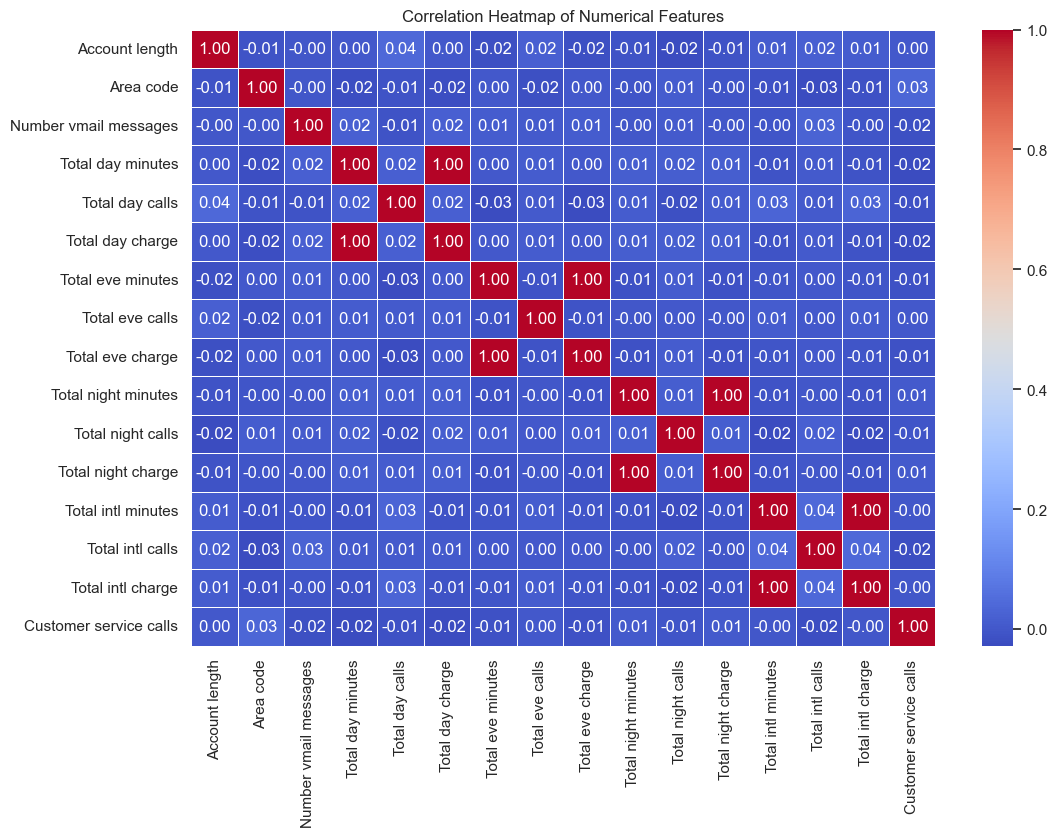

In [10]:
# 1. Define 'numerical_cols' by selecting only number-based columns from the dataframe
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 2. Now calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

# 3. Visualize using a Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 📊 Task 2: Final Insights Summary

| Analysis Type | Key Finding | Business Impact |
| :--- | :--- | :--- |
| **Distribution** | `Total day minutes` is normally distributed around 180 mins. | Most customers have predictable usage habits. |
| **Outliers** | Boxplot shows some customers talk >300 mins or <50 mins. | These "Outliers" are high-value customers or inactive ones. |
| **Scatter Plot** | Perfect linear relationship between Minutes and Charge. | Confirms that the billing system is strictly usage-based. |
| **Correlation** | `Customer service calls` has a low correlation with usage. | Suggests that service issues are independent of how much a user talks. |

**Conclusion:** The statistical analysis confirms data consistency. The strong correlation between minutes and charges is expected, while the distribution of service calls will be a key factor for the Level 3 Churn prediction task.